# Baseline Current Model Executed: World Cup 2026

**Objetivo**: Entrenar un clasificador XGBoost robusto sobre partidos históricos internacionales (Copas del Mundo + Eurocopas + Copa América = ~1,500+ partidos) para predecir resultados, y simular el torneo 2026 con Monte Carlo (50,000 iteraciones) para estimar probabilidades de campeonato.

## Mejoras clave del modelo
- **Sistema Elo dinámico**: Rating calculado sobre TODOS los partidos históricos, capturando fuerza actual de cada selección
- **3x más datos de entrenamiento**: No solo mundiales — incluye Eurocopas y Copa América
- **Features temporales consistentes**: sin valor de mercado ni ranking sintético en training
- **Optimización exhaustiva**: Optuna con 200 trials de búsqueda de hiperparámetros
- **50,000 simulaciones Monte Carlo** para estimaciones estables

## Secciones
1. Importaciones y configuración
2. Carga y unificación de datos de partidos
3. Sistema Elo dinámico
4. Reconstrucción temporal de features
5. Ingeniería de features a nivel de partido
6. Entrenamiento XGBoost con LOTO-CV + Optuna
7. Diagnósticos del modelo
8. Simulación Monte Carlo del torneo 2026
9. Visualización de resultados y comparación con momios

## 1. Importaciones y Configuración

In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'Models':
    os.chdir('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import optuna
from sklearn.metrics import log_loss, accuracy_score
from sklearn.calibration import calibration_curve
from collections import defaultdict
import glob
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

SEED = 42
rng = np.random.default_rng(SEED)

print('Librerías cargadas correctamente.')

/Users/bernardodelrio/Library/Python/3.14/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías cargadas correctamente.


## 2. Carga y Unificación de Datos de Partidos

Combinamos **tres fuentes** de partidos internacionales oficiales en un solo dataset unificado.

In [2]:
# --- 2.1 Carga de datos ---
wc_matches = pd.read_csv('Data/WorldCupHistory/matches_1930_2022.csv')
worldcups = pd.read_csv('Data/WorldCupHistory/worldcups.csv')
rankings = pd.read_csv('Data/ranking_mundial_2026_v2.csv')
master = pd.read_csv('Data/master_dataset_64.csv')
momios = pd.read_csv('Data/momios_mundial2026.csv')
copa = pd.read_csv('Data/Copa_America.csv')

# Euro - cargar todos los torneos
euro_files = sorted(glob.glob('Data/euro_histoia/*.csv'))
euro_all = []
for f in euro_files:
    df = pd.read_csv(f, usecols=['home_team', 'away_team', 'home_team_code', 'away_team_code',
                                  'home_score', 'away_score', 'year', 'date', 'round'])
    df = df.dropna(subset=['home_score', 'away_score'])
    euro_all.append(df)
euro = pd.concat(euro_all, ignore_index=True)

print(f'Partidos Copa del Mundo: {len(wc_matches)}')
print(f'Partidos Eurocopa: {len(euro)}')
print(f'Partidos Copa América: {len(copa)}')
print(f'TOTAL: {len(wc_matches) + len(euro) + len(copa)} partidos internacionales')

Partidos Copa del Mundo: 964
Partidos Eurocopa: 388
Partidos Copa América: 212
TOTAL: 1564 partidos internacionales


In [3]:
# --- 2.2 Mapeo maestro de nombres a códigos ---
name_to_code = dict(zip(rankings['team_name'], rankings['country_code']))

# Equipos históricos y variantes de nombre
name_to_code.update({
    # Equipos históricos
    'West Germany': 'GER', 'Germany DR': 'GER_DR', 'Yugoslavia': 'YUG',
    'FR Yugoslavia': 'SRB', 'Serbia and Montenegro': 'SRB', 'Soviet Union': 'URS',
    'Czechoslovakia': 'CZE', 'Czech Republic': 'CZE', 'Zaire': 'COD',
    'Dutch East Indies': 'IDN', 'China PR': 'CHN', 'Korea DPR': 'PRK',
    'United States': 'USA', 'Trinidad and Tobago': 'TTO', 'United Arab Emirates': 'ARE',
    'Costa Rica': 'CRC', 'El Salvador': 'SLV', 'Serbia': 'SRB', 'Russia': 'RUS',
    'Togo': 'TGO', 'Honduras': 'HON', 'Cuba': 'CUB', 'Iceland': 'ISL',
    'Slovenia': 'SVN', 'Greece': 'GRE', 'Angola': 'ANG', 'Cameroon': 'CMR',
    'Nigeria': 'NGA', 'Bulgaria': 'BUL', 'Hungary': 'HUN', 'Peru': 'PER',
    'Chile': 'CHI', 'Bolivia': 'BOL', 'Israel': 'ISR', 'Kuwait': 'KUW',
    'Denmark': 'DEN',
    # Copa América (portugués)
    'Brasil': 'BRA', 'Equador': 'ECU', 'Paraguai': 'PAR', 'Uruguai': 'URU',
    'EUA': 'USA', 'Mexico': 'MEX', 'Japao': 'JPN', 'Catar': 'QAT',
    'Haiti': 'HAI', 'Venezuela': 'VEN', 'Jamaica': 'JAM', 'Panama': 'PAN',
    # Euro variantes
    'Georgia': 'GEO', 'North Macedonia': 'MKD',
})

# Mapeo de ganadores de mundiales
winner_name_to_code = {
    'Uruguay': 'URU', 'Italy': 'ITA', 'Brazil': 'BRA', 'West Germany': 'GER',
    'England': 'ENG', 'Argentina': 'ARG', 'Germany': 'GER', 'France': 'FRA', 'Spain': 'ESP'
}

# Alias entre momios y master dataset
code_alias = {'COD': 'CGO'}  # DR Congo

# Aplicar mapeo a wc_matches (necesario para acumulados WC)
wc_matches['home_code'] = wc_matches['home_team'].map(name_to_code)
wc_matches['away_code'] = wc_matches['away_team'].map(name_to_code)

# Verificar mapeo para World Cup
all_wc_teams = set(wc_matches['home_team'].unique()) | set(wc_matches['away_team'].unique())
unmapped_wc = all_wc_teams - set(name_to_code.keys())
print(f'Equipos WC sin mapeo: {unmapped_wc if unmapped_wc else "ninguno ✅"}')

# Verificar mapeo para Copa América
all_copa_teams = set(copa['Casa'].unique()) | set(copa['Fora'].unique())
unmapped_copa = all_copa_teams - set(name_to_code.keys())
print(f'Equipos Copa sin mapeo: {unmapped_copa if unmapped_copa else "ninguno ✅"}')

Equipos WC sin mapeo: ninguno ✅
Equipos Copa sin mapeo: ninguno ✅


In [4]:
# --- 2.3 Unificar todos los partidos en un solo DataFrame ---

def unify_matches():
    """Crear un dataset unificado con: date, home_code, away_code, home_score, away_score, tournament, year, stage"""
    rows = []
    
    # 1) World Cup matches
    for _, m in wc_matches.iterrows():
        hc = name_to_code.get(m['home_team'])
        ac = name_to_code.get(m['away_team'])
        if hc and ac:
            rows.append({
                'date': m['Date'], 'home_code': hc, 'away_code': ac,
                'home_score': m['home_score'], 'away_score': m['away_score'],
                'tournament': 'WC', 'year': m['Year'], 'stage': m['Round'],
                'tournament_weight': 1.0,  # Peso máximo para mundiales
            })
    
    # 2) Euro matches
    for _, m in euro.iterrows():
        hc = m.get('home_team_code')
        ac = m.get('away_team_code')
        if pd.isna(hc) or pd.isna(ac):
            hc = name_to_code.get(m.get('home_team'))
            ac = name_to_code.get(m.get('away_team'))
        if hc and ac:
            rows.append({
                'date': m.get('date', f"{int(m['year'])}-06-15"),
                'home_code': hc, 'away_code': ac,
                'home_score': m['home_score'], 'away_score': m['away_score'],
                'tournament': 'EURO', 'year': int(m['year']), 'stage': m.get('round', ''),
                'tournament_weight': 0.85,  # Eurocopa es casi tan competitiva como WC
            })
    
    # 3) Copa América matches
    for _, m in copa.iterrows():
        hc = name_to_code.get(m['Casa'])
        ac = name_to_code.get(m['Fora'])
        if hc and ac:
            rows.append({
                'date': m['Data'],
                'home_code': hc, 'away_code': ac,
                'home_score': m['Gols Casa'], 'away_score': m['Gols Fora'],
                'tournament': 'COPA', 'year': int(m['Edição']), 'stage': m['Fase'],
                'tournament_weight': 0.80,  # Copa América ligeramente menor
            })
    
    df = pd.DataFrame(rows)
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.sort_values('date').reset_index(drop=True)
    
    # Derivar outcome
    df['outcome'] = np.where(df['home_score'] > df['away_score'], 2,
                    np.where(df['home_score'] < df['away_score'], 0, 1))
    
    # Determinar fase de eliminación directa
    knockout_keywords = {'Final', 'Semi', 'Quarter', 'Round of 16', 'Round of 32',
                        'FINAL', 'SEMIFINAL', 'QUARTER', 'ROUND_OF_16',
                        'Semifinal', 'Cuartos', 'Octavos', 'Third-place',
                        'Second round', 'Final stage'}
    df['is_knockout'] = df['stage'].apply(
        lambda s: 1 if any(kw.lower() in str(s).lower() for kw in knockout_keywords) else 0
    )
    
    return df

all_matches = unify_matches()
print(f'Dataset unificado: {len(all_matches)} partidos')
print(f'  WC:   {(all_matches["tournament"]=="WC").sum()}')
print(f'  EURO: {(all_matches["tournament"]=="EURO").sum()}')
print(f'  COPA: {(all_matches["tournament"]=="COPA").sum()}')
print(f'  Rango: {all_matches["date"].min()} → {all_matches["date"].max()}')
print(f'  Equipos únicos: {len(set(all_matches["home_code"]) | set(all_matches["away_code"]))}')

Dataset unificado: 1564 partidos
  WC:   964
  EURO: 388
  COPA: 212
  Rango: 1930-07-13 00:00:00 → 2024-07-14 00:00:00
  Equipos únicos: 91


## 3. Sistema Elo Dinámico

Calculamos un **rating Elo** para cada selección a lo largo del tiempo. El Elo captura la fuerza actual de un equipo de forma dinámica: una victoria contra un rival fuerte sube más puntos que contra uno débil.

Parámetros:
- **K=40** para torneos (partidos competitivos, alta volatilidad)
- **Elo inicial = 1500** para todos los equipos
- Los equipos heredan ratings de sus predecesores (West Germany → Germany, etc.)

In [5]:
# --- 3.1 Cálculo de Elo sobre todos los partidos ---

K_FACTOR = 40  # Factor K alto para torneos internacionales
ELO_INIT = 1500

def compute_elo_history(matches_df):
    """
    Calcular Elo para cada equipo después de cada partido.
    Retorna: dict con (team_code) -> current_elo, y un historial completo.
    """
    elo_current = defaultdict(lambda: ELO_INIT)
    elo_snapshots = []
    
    for idx, match in matches_df.iterrows():
        home = match['home_code']
        away = match['away_code']
        
        home_elo = elo_current[home]
        away_elo = elo_current[away]
        
        # Probabilidad esperada (fórmula Elo estándar)
        exp_home = 1 / (1 + 10 ** ((away_elo - home_elo) / 400))
        exp_away = 1 - exp_home
        
        # Resultado real
        outcome = match['outcome']
        if outcome == 2:
            actual_home, actual_away = 1.0, 0.0
        elif outcome == 0:
            actual_home, actual_away = 0.0, 1.0
        else:
            actual_home, actual_away = 0.5, 0.5
        
        # Guardar snapshot ANTES de actualizar
        elo_snapshots.append({
            'date': match['date'],
            'year': match['year'],
            'home_code': home,
            'away_code': away,
            'home_elo_before': home_elo,
            'away_elo_before': away_elo,
            'tournament': match['tournament'],
            'outcome': outcome,
        })
        
        # Actualizar Elo con factor K ponderado por importancia del torneo
        k = K_FACTOR * match.get('tournament_weight', 1.0)
        elo_current[home] += k * (actual_home - exp_home)
        elo_current[away] += k * (actual_away - exp_away)
    
    return elo_current, pd.DataFrame(elo_snapshots)

elo_final, elo_history = compute_elo_history(all_matches)

# Mostrar top 20 Elo actuales
elo_sorted = sorted(elo_final.items(), key=lambda x: -x[1])
print('Top 20 Elo actuales (tras procesar todos los partidos):')
for i, (team, elo) in enumerate(elo_sorted[:20], 1):
    print(f'  {i:2d}. {team}: {elo:.0f}')

print(f'\nTotal equipos con Elo: {len(elo_final)}')

Top 20 Elo actuales (tras procesar todos los partidos):
   1. FRA: 1720
   2. ESP: 1714
   3. ARG: 1712
   4. NED: 1705
   5. BRA: 1686
   6. GER: 1672
   7. ITA: 1651
   8. ENG: 1627
   9. BEL: 1609
  10. CRO: 1603
  11. COL: 1603
  12. URU: 1600
  13. CHI: 1596
  14. POR: 1592
  15. FRG: 1579
  16. URS: 1574
  17. SUI: 1570
  18. PER: 1559
  19. SWE: 1558
  20. MEX: 1535

Total equipos con Elo: 91


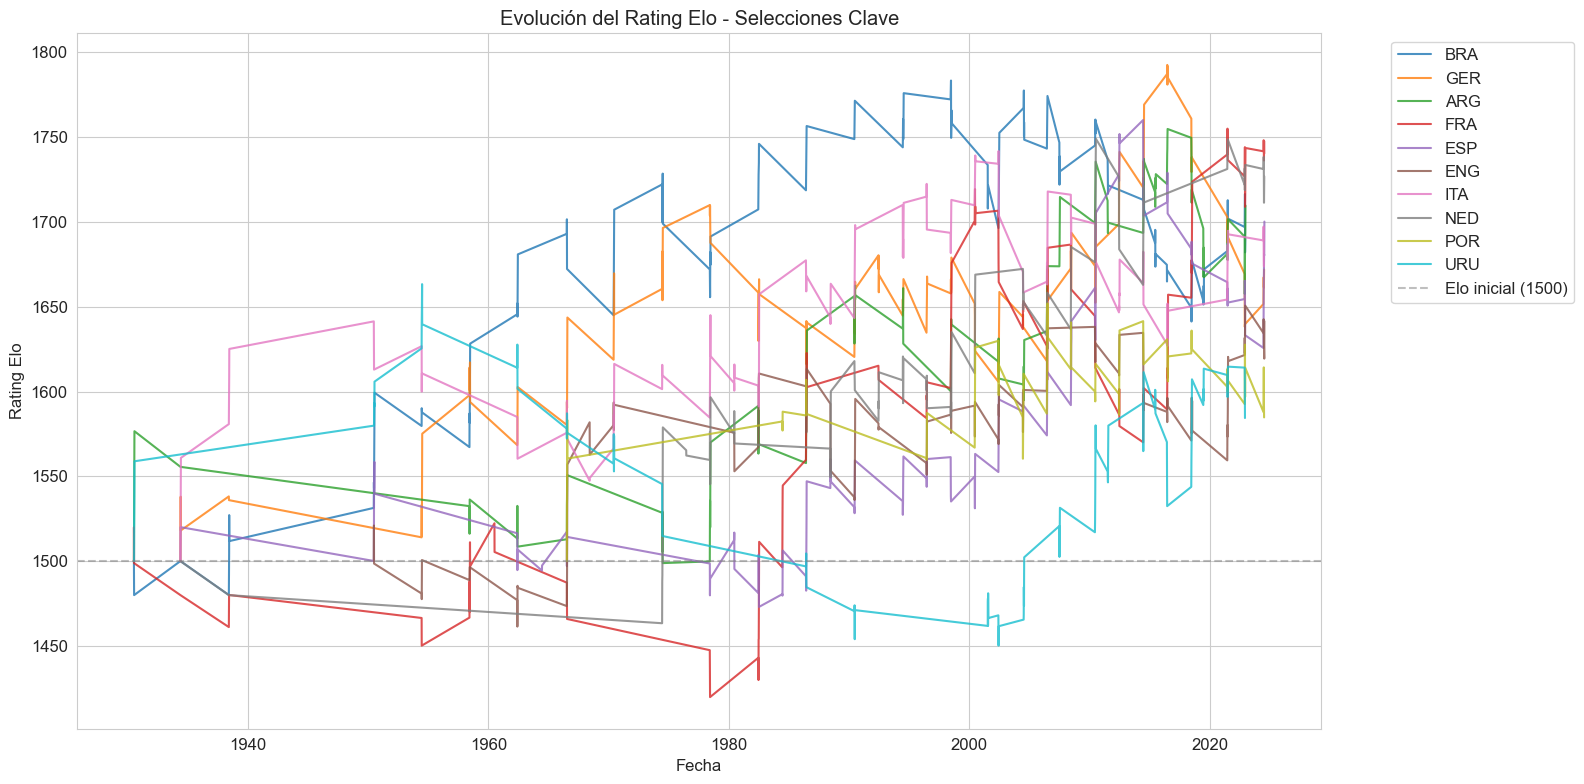

In [6]:
# --- 3.2 Visualizar evolución de Elo para equipos clave ---

teams_to_plot = ['BRA', 'GER', 'ARG', 'FRA', 'ESP', 'ENG', 'ITA', 'NED', 'POR', 'URU']
colors = plt.cm.tab10(np.linspace(0, 1, len(teams_to_plot)))

fig, ax = plt.subplots(figsize=(16, 8))

for team, color in zip(teams_to_plot, colors):
    team_elo = elo_history[
        (elo_history['home_code'] == team) | (elo_history['away_code'] == team)
    ].copy()
    
    team_elo['elo'] = np.where(
        team_elo['home_code'] == team,
        team_elo['home_elo_before'],
        team_elo['away_elo_before']
    )
    
    if len(team_elo) > 0:
        ax.plot(team_elo['date'], team_elo['elo'], label=team, alpha=0.8, linewidth=1.5, color=color)

ax.axhline(y=ELO_INIT, color='gray', linestyle='--', alpha=0.5, label='Elo inicial (1500)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Rating Elo')
ax.set_title('Evolución del Rating Elo - Selecciones Clave')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [7]:
# --- 3.3 Acumulados históricos de WC (títulos, win%, gc/game, experiencia) ---
# Acumular para TODOS los equipos que hayan jugado algún WC,
# no solo los del torneo actual. Así Italia conserva sus 4 títulos
# aunque no participara en 2022.

wc_years = sorted(wc_matches['Year'].unique())

wc_team_accum = defaultdict(lambda: {'wins': 0, 'draws': 0, 'losses': 0, 'gf': 0, 'gc': 0, 'games': 0})
wc_cumulative = {}
wc_titles_cumulative = {}
titles_by_team = defaultdict(int)
all_wc_teams_ever = set()

for year in wc_years:
    year_teams = set(wc_matches[wc_matches['Year'] == year]['home_code'].dropna()) | \
                 set(wc_matches[wc_matches['Year'] == year]['away_code'].dropna())
    all_wc_teams_ever |= year_teams
    
    # Snapshot ANTES del torneo para TODOS los equipos históricos
    for team in all_wc_teams_ever:
        acc = wc_team_accum[team]
        g = acc['games']
        wc_cumulative[(team, year)] = {
            'wc_win_pct': acc['wins'] / g if g > 0 else 0.0,
            'wc_gc_per_game': acc['gc'] / g if g > 0 else 0.0,
            'wc_experience': g,
        }
        wc_titles_cumulative[(team, year)] = titles_by_team[team]
    
    for _, row in wc_matches[wc_matches['Year'] == year].iterrows():
        home, away = row.get('home_code'), row.get('away_code')
        if pd.isna(home) or pd.isna(away): continue
        hs, as_ = row['home_score'], row['away_score']
        wc_team_accum[home]['games'] += 1; wc_team_accum[away]['games'] += 1
        wc_team_accum[home]['gf'] += hs; wc_team_accum[home]['gc'] += as_
        wc_team_accum[away]['gf'] += as_; wc_team_accum[away]['gc'] += hs
        if hs > as_:
            wc_team_accum[home]['wins'] += 1; wc_team_accum[away]['losses'] += 1
        elif hs < as_:
            wc_team_accum[away]['wins'] += 1; wc_team_accum[home]['losses'] += 1
        else:
            wc_team_accum[home]['draws'] += 1; wc_team_accum[away]['draws'] += 1
    
    winner_row = worldcups[worldcups['year'] == year]
    if len(winner_row) > 0:
        wn = winner_row.iloc[0]['winner']
        wc = winner_name_to_code.get(wn, name_to_code.get(wn))
        if wc: titles_by_team[wc] += 1

ranking_by_year = {}
for _, row in rankings.iterrows():
    ranking_by_year[(row['country_code'], int(row['year']))] = row['ranking']

def get_ranking(team_code, year):
    real = ranking_by_year.get((team_code, year))
    if real is not None: return real
    stats = wc_cumulative.get((team_code, year), {})
    wp = stats.get('wc_win_pct', 0.0)
    exp = stats.get('wc_experience', 0)
    t = wc_titles_cumulative.get((team_code, year), 0)
    strength = wp * 0.5 + min(t * 0.15, 0.45) + min(exp / 50, 0.2)
    return max(1, int(80 - strength * 79))

print(f'Stats acumuladas WC: {len(wc_cumulative)} pares (equipo, año)')
print(f'Equipos con historial WC: {len(all_wc_teams_ever)}')
print(f'\nTítulos WC antes de 2022 (verificación):')
for team in ['BRA', 'GER', 'ITA', 'ARG', 'FRA', 'ENG', 'ESP', 'URU']:
    print(f'  {team}: {wc_titles_cumulative.get((team, 2022), 0)}')

Stats acumuladas WC: 1125 pares (equipo, año)
Equipos con historial WC: 82

Títulos WC antes de 2022 (verificación):
  BRA: 5
  GER: 4
  ITA: 4
  ARG: 2
  FRA: 2
  ENG: 1
  ESP: 1
  URU: 2


## 4. Reconstrucción Temporal de Features

Nota: El Elo ya está calculado y embebido en `elo_history`. Ahora construimos features adicionales para el head-to-head y forma reciente.

In [8]:
# --- 4.1 Forma reciente: resultados en los últimos N partidos antes de cada partido ---

def compute_recent_form(matches_df, window=10):
    """
    Para cada partido, calcular el win% y goles/partido en los últimos `window` partidos
    de cada equipo (de cualquier torneo).
    """
    team_match_history = defaultdict(list)  # team -> [(date, outcome, gf, gc), ...]
    form_data = []
    
    for idx, match in matches_df.iterrows():
        home = match['home_code']
        away = match['away_code']
        
        # Forma reciente del local
        home_recent = team_match_history[home][-window:]
        if len(home_recent) >= 3:
            home_form_wp = sum(1 for _, o, _, _ in home_recent if o == 'W') / len(home_recent)
            home_form_gf = np.mean([gf for _, _, gf, _ in home_recent])
            home_form_gc = np.mean([gc for _, _, _, gc in home_recent])
        else:
            home_form_wp, home_form_gf, home_form_gc = 0.33, 1.0, 1.0
        
        # Forma reciente del visitante
        away_recent = team_match_history[away][-window:]
        if len(away_recent) >= 3:
            away_form_wp = sum(1 for _, o, _, _ in away_recent if o == 'W') / len(away_recent)
            away_form_gf = np.mean([gf for _, _, gf, _ in away_recent])
            away_form_gc = np.mean([gc for _, _, _, gc in away_recent])
        else:
            away_form_wp, away_form_gf, away_form_gc = 0.33, 1.0, 1.0
        
        form_data.append({
            'home_form_wp': home_form_wp,
            'home_form_gf': home_form_gf,
            'home_form_gc': home_form_gc,
            'away_form_wp': away_form_wp,
            'away_form_gf': away_form_gf,
            'away_form_gc': away_form_gc,
        })
        
        # Actualizar historial
        hs, as_ = match['home_score'], match['away_score']
        if hs > as_:
            team_match_history[home].append((match['date'], 'W', hs, as_))
            team_match_history[away].append((match['date'], 'L', as_, hs))
        elif hs < as_:
            team_match_history[home].append((match['date'], 'L', hs, as_))
            team_match_history[away].append((match['date'], 'W', as_, hs))
        else:
            team_match_history[home].append((match['date'], 'D', hs, as_))
            team_match_history[away].append((match['date'], 'D', as_, hs))
    
    return pd.DataFrame(form_data), team_match_history

form_df, team_histories = compute_recent_form(all_matches, window=10)
print(f'Forma reciente calculada para {len(form_df)} partidos.')
print(f'Equipos con historial: {len(team_histories)}')

Forma reciente calculada para 1564 partidos.
Equipos con historial: 91


In [9]:
# --- 4.2 Features de jugadores (datos de Transfermarkt) ---

players_df = pd.read_csv('Data/transfermarkt_players.csv')
print(f'Datos de jugadores cargados: {len(players_df)} registros')
print(f'Equipos: {players_df["country_code"].nunique()}, Años: {sorted(players_df["year"].unique())}')

def compute_player_features_all(df):
    features = {}
    for (code, year), group in df.groupby(['country_code', 'year']):
        values = group['market_value_eur_m'].dropna().sort_values(ascending=False)
        if len(values) < 3:
            continue
        total_value = values.sum()
        star_concentration = values.head(3).sum() / total_value if total_value > 0 else 0
        top5_avg_value = values.head(5).mean()
        gk_vals = group[group['position'] == 'GK']['market_value_eur_m'].dropna()
        gk_value = gk_vals.max() if len(gk_vals) > 0 else 0
        squad_depth_ratio = values.median() / values.mean() if values.mean() > 0 else 0
        age_weighted = 0
        for _, p in group.dropna(subset=['market_value_eur_m', 'age']).iterrows():
            weight = max(0, (30 - p['age'])) / 10
            age_weighted += p['market_value_eur_m'] * weight
        top_league_pct = group['is_top_league'].mean() if 'is_top_league' in group.columns else 0
        features[(code, year)] = {
            'star_concentration': star_concentration,
            'top5_avg_value': top5_avg_value,
            'gk_value': gk_value,
            'squad_depth_ratio': squad_depth_ratio,
            'age_weighted_value': age_weighted,
            'top_league_pct': top_league_pct,
        }
    return features

player_features = compute_player_features_all(players_df)
print(f'\nFeatures calculadas para {len(player_features)} pares (equipo, año)')

player_years = sorted(set(y for _, y in player_features.keys()))
print(f'Años disponibles: {player_years}')

def get_player_features(team_code, year):
    for y in reversed(player_years):
        if y <= year and (team_code, y) in player_features:
            return player_features[(team_code, y)]
    return {'star_concentration': 0, 'top5_avg_value': 0, 'gk_value': 0,
            'squad_depth_ratio': 0, 'age_weighted_value': 0, 'top_league_pct': 0}

print(f'\nVerificación:')
for team, yr in [('ENG', 2025), ('NOR', 2025), ('ARG', 2025), ('FRA', 2018)]:
    f = get_player_features(team, yr)
    if f['top5_avg_value'] > 0:
        print(f'  {team} {yr}: star_conc={f["star_concentration"]:.2f}, top5_avg={f["top5_avg_value"]:.1f}M, '
              f'gk={f["gk_value"]:.1f}M, depth={f["squad_depth_ratio"]:.2f}, '
              f'age_wt={f["age_weighted_value"]:.0f}, top_lg={f["top_league_pct"]:.2f}')

Datos de jugadores cargados: 39903 registros
Equipos: 48, Años: [np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]



Features calculadas para 898 pares (equipo, año)
Años disponibles: [np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Verificación:
  ENG 2025: star_conc=0.25, top5_avg=142.0M, gk=20.0M, depth=0.83, age_wt=1063, top_lg=0.93
  NOR 2025: star_conc=0.58, top5_avg=78.0M, gk=1.7M, depth=0.26, age_wt=324, top_lg=0.47
  ARG 2025: star_conc=0.27, top5_avg=80.0M, gk=25.0M, depth=0.63, age_wt=443, top_lg=0.58
  FRA 2018: star_conc=0.27, top5_avg=126.0M, gk=25.0M, depth=0.69, age_wt=832, top_lg=0.46


## 5. Ingeniería de Features a Nivel de Partido

Cada fila = un partido. Features como **diferencias** entre equipos. Ahora con 10 features:
- **Elo delta** (la más importante — captura fuerza actual)
- **Forma reciente** (win%, goles)
- **Historial mundialista** (win%, goles en contra, títulos, experiencia)
- **Fase** (grupo vs eliminación directa)

In [10]:
# --- 5.1 Construir dataset de entrenamiento con features expandidas ---
# FIX: Removido delta_market_value (temporalmente inválido).
# FIX: Removido delta_ranking (34.9% de los partidos requerían ranking sintético
#      porque el archivo de ranking solo cubre los 64 equipos de 2026).
# FIX: WC cumulative lookup ahora busca el año MÁS RECIENTE <= year
#      con datos para ese equipo, no solo el más cercano.

feature_cols = [
    'delta_elo',              # Diferencia de Elo (LA feature principal)
    'delta_form_wp',          # Diferencia de win% reciente (últimos 10 partidos)
    'delta_form_gf',          # Diferencia de goles a favor recientes
    'delta_form_gc',          # Diferencia de goles en contra recientes
    'delta_wc_win_pct',       # Diferencia de win% histórico en WC
    'delta_wc_gc_per_game',   # Diferencia de goles en contra/partido en WC
    'delta_wc_titles',        # Diferencia de títulos mundiales
    'delta_wc_experience',    # Diferencia de partidos jugados en WC
    'is_knockout',            # 1 si es eliminación directa
    'tournament_weight',      # Peso del torneo (WC=1.0, EURO=0.85, COPA=0.80)
    'delta_star_concentration',  # Diferencia de concentración en estrellas
    'delta_top5_avg_value',      # Diferencia de valor promedio top 5
    'delta_gk_value',            # Diferencia de valor del portero
    'delta_squad_depth_ratio',   # Diferencia de profundidad de plantilla
    'delta_age_weighted_value',  # Diferencia de valor ponderado por edad
    'delta_top_league_pct',      # Diferencia de % en ligas top
]

def get_wc_stats(team, year):
    """Buscar stats WC acumuladas para el año WC más reciente <= year."""
    for y in reversed(wc_years):
        if y <= year and (team, y) in wc_cumulative:
            return wc_cumulative[(team, y)], wc_titles_cumulative.get((team, y), 0)
    return {'wc_win_pct': 0, 'wc_gc_per_game': 0, 'wc_experience': 0}, 0

rows = []
for i, (_, match) in enumerate(all_matches.iterrows()):
    year = match['year']
    home = match['home_code']
    away = match['away_code']
    
    elo_row = elo_history.iloc[i]
    home_elo = elo_row['home_elo_before']
    away_elo = elo_row['away_elo_before']
    
    form_row = form_df.iloc[i]
    
    home_wc, home_titles = get_wc_stats(home, year)
    away_wc, away_titles = get_wc_stats(away, year)
    
    row = {
        'year': year,
        'home_team': home,
        'away_team': away,
        'tournament': match['tournament'],
        'delta_elo': home_elo - away_elo,
        'delta_form_wp': form_row['home_form_wp'] - form_row['away_form_wp'],
        'delta_form_gf': form_row['home_form_gf'] - form_row['away_form_gf'],
        'delta_form_gc': form_row['home_form_gc'] - form_row['away_form_gc'],
        'delta_wc_win_pct': home_wc['wc_win_pct'] - away_wc['wc_win_pct'],
        'delta_wc_gc_per_game': home_wc['wc_gc_per_game'] - away_wc['wc_gc_per_game'],
        'delta_wc_titles': home_titles - away_titles,
        'delta_wc_experience': home_wc['wc_experience'] - away_wc['wc_experience'],
        'is_knockout': match['is_knockout'],
        'tournament_weight': match['tournament_weight'],
        'outcome': match['outcome'],
    }
    
    # Features de jugadores (6 nuevas)
    home_pf = get_player_features(home, year)
    away_pf = get_player_features(away, year)
    row['delta_star_concentration'] = home_pf['star_concentration'] - away_pf['star_concentration']
    row['delta_top5_avg_value'] = home_pf['top5_avg_value'] - away_pf['top5_avg_value']
    row['delta_gk_value'] = home_pf['gk_value'] - away_pf['gk_value']
    row['delta_squad_depth_ratio'] = home_pf['squad_depth_ratio'] - away_pf['squad_depth_ratio']
    row['delta_age_weighted_value'] = home_pf['age_weighted_value'] - away_pf['age_weighted_value']
    row['delta_top_league_pct'] = home_pf['top_league_pct'] - away_pf['top_league_pct']
    
    rows.append(row)

train_df = pd.DataFrame(rows)
print(f'Dataset de entrenamiento: {len(train_df)} partidos × {len(feature_cols)} features')
print(f'\nDistribución de resultados:')
for val, label in {0: 'Victoria visitante', 1: 'Empate', 2: 'Victoria local'}.items():
    count = (train_df['outcome'] == val).sum()
    print(f'  {label}: {count} ({count/len(train_df)*100:.1f}%)')
print(f'\nPor torneo:')
print(train_df.groupby('tournament').size())
print(f'\nEstadísticas de features:')
train_df[feature_cols].describe().round(3)

Dataset de entrenamiento: 1564 partidos × 16 features

Distribución de resultados:
  Victoria visitante: 407 (26.0%)
  Empate: 396 (25.3%)
  Victoria local: 761 (48.7%)

Por torneo:
tournament
COPA    212
EURO    388
WC      964
dtype: int64

Estadísticas de features:


,delta_elo,delta_form_wp,delta_form_gf,delta_form_gc,delta_wc_win_pct,delta_wc_gc_per_game,delta_wc_titles,delta_wc_experience,is_knockout,tournament_weight,delta_star_concentration,delta_top5_avg_value,delta_gk_value,delta_squad_depth_ratio,delta_age_weighted_value,delta_top_league_pct
count,1564.000,1564.000,1546.000,1546.000,1564.000,1564.000,1564.000,1564.000,1564.000,1564.000,1564.000,1564.00,1564.000,1564.000,1564.000,1564.000
mean,29.442,0.050,0.133,-0.104,0.057,-0.055,0.335,7.288,0.258,0.936,0.006,3.27,1.331,0.023,21.237,0.012
std,118.743,0.261,0.731,0.791,0.300,1.157,1.654,32.060,0.437,0.083,0.166,26.09,14.160,0.320,187.231,0.160
min,-388.936,-0.800,-3.333,-4.233,-0.833,-6.529,-5.000,-94.000,0.000,0.800,-0.789,-134.00,-88.750,-1.009,-1102.200,-0.896
25%,-43.880,-0.100,-0.300,-0.600,-0.135,-0.667,0.000,-9.000,0.000,0.850,0.000,0.00,0.000,0.000,0.000,0.000
50%,23.924,0.047,0.100,-0.100,0.053,-0.028,0.000,4.000,0.000,1.000,0.000,0.00,0.000,0.000,0.000,0.000
75%,110.173,0.200,0.600,0.300,0.264,0.503,1.000,24.000,1.000,1.000,0.000,0.00,0.000,0.000,0.000,0.000
max,385.834,0.900,3.300,4.100,1.000,6.930,5.000,104.000,1.000,1.000,1.000,134.00,87.000,0.982,1102.200,0.896


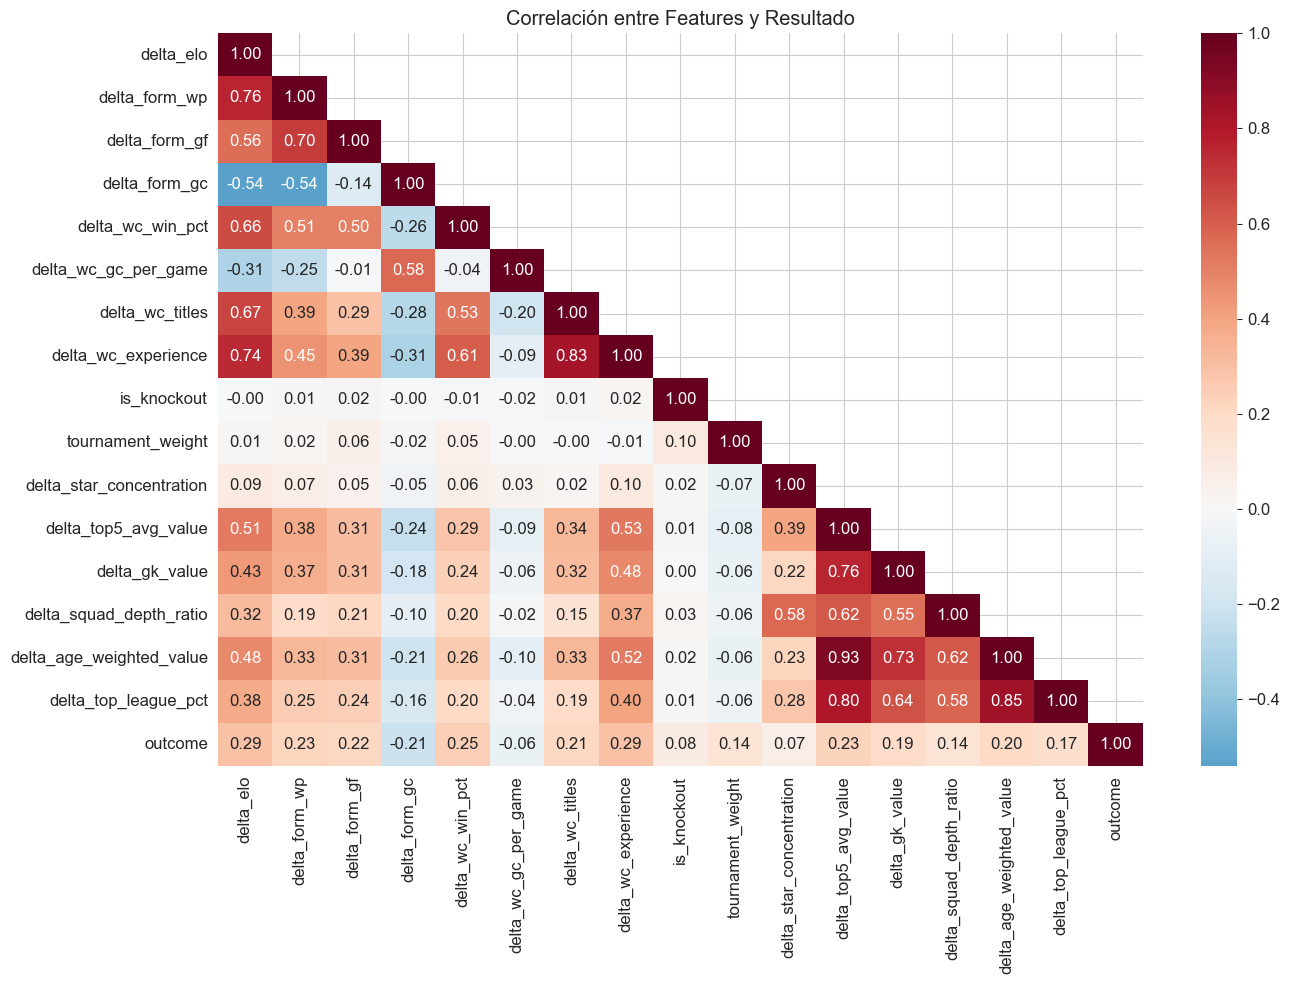

In [11]:
# --- 5.2 Matriz de correlación ---
fig, ax = plt.subplots(figsize=(14, 10))
corr = train_df[feature_cols + ['outcome']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=ax, mask=mask)
ax.set_title('Correlación entre Features y Resultado')
plt.tight_layout()
plt.show()

## 6. Entrenamiento XGBoost con LOTO-CV + Optuna

**Leave-One-Tournament-Out**: entrenamos con todos los torneos anteriores, probamos en el siguiente.

**Optuna**: búsqueda bayesiana de hiperparámetros con 200 trials, optimizando log-loss promedio en los folds de validación. Esto toma varios minutos.

In [12]:
# --- 6.1 Definir folds temporales para LOTO-CV ---
# Usamos torneos WC como puntos de corte (los más importantes para validar)
# Pero entrenamos con TODOS los datos (WC + Euro + Copa) anteriores al torneo de prueba

X = train_df[feature_cols].values
y = train_df['outcome'].values
years = train_df['year'].values
tournaments = train_df['tournament'].values

# Folds de test: Mundiales 2002-2022
# El test incluye SOLO partidos de ese WC
# El train incluye TODOS los partidos (WC + Euro + Copa) de años anteriores
test_wc_years = [2002, 2006, 2010, 2014, 2018, 2022]
actual_winners = {2002: 'BRA', 2006: 'ITA', 2010: 'ESP', 2014: 'GER', 2018: 'FRA', 2022: 'ARG'}

def get_loto_folds():
    """Generar folds de train/test para LOTO-CV."""
    folds = []
    for test_year in test_wc_years:
        # Train: todos los partidos de cualquier torneo ANTES del año de test
        train_mask = years < test_year
        # Test: solo partidos del WC de ese año
        test_mask = (years == test_year) & (tournaments == 'WC')
        
        if test_mask.sum() > 0 and train_mask.sum() > 0:
            folds.append((train_mask, test_mask, test_year))
    return folds

folds = get_loto_folds()
for train_mask, test_mask, year in folds:
    print(f'WC {year}: train={train_mask.sum()} partidos, test={test_mask.sum()} partidos')

print(f'\nTotal folds: {len(folds)}')

WC 2002: train=748 partidos, test=64 partidos
WC 2006: train=869 partidos, test=64 partidos
WC 2010: train=990 partidos, test=64 partidos
WC 2014: train=1111 partidos, test=64 partidos
WC 2018: train=1284 partidos, test=64 partidos
WC 2022: train=1449 partidos, test=64 partidos

Total folds: 6


In [13]:
# --- 6.2 Optimización de hiperparámetros con Optuna (200 trials) ---
# FIX: Nested CV — Optuna tunes on inner folds (2002-2014 only).
# Final evaluation on ALL 6 folds is done separately in cell 6.3.

inner_folds = [(tm, te, y) for tm, te, y in folds if y <= 2014]
print(f'Inner folds para tuning: {[y for _,_,y in inner_folds]}')
print(f'Outer folds para evaluación final: {[y for _,_,y in folds]}')

def objective(trial):
    params = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'random_state': SEED,
        'use_label_encoder': False,
        'eval_metric': 'mlogloss',
        'verbosity': 0,
    }
    
    fold_losses = []
    for train_mask, test_mask, test_year in inner_folds:
        X_train, X_test = X[train_mask], X[test_mask]
        y_train, y_test = y[train_mask], y[test_mask]
        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        y_proba = model.predict_proba(X_test)
        fold_losses.append(log_loss(y_test, y_proba))
    return np.mean(fold_losses)

print(f'\nIniciando optimización Optuna (200 trials en {len(inner_folds)} inner folds)...')
print('Esto tomará varios minutos.\n')

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f'\nOptimización completada.')
print(f'Mejor log-loss promedio (inner folds): {study.best_value:.4f}')
print(f'Mejores hiperparámetros:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Inner folds para tuning: [2002, 2006, 2010, 2014]
Outer folds para evaluación final: [2002, 2006, 2010, 2014, 2018, 2022]

Iniciando optimización Optuna (200 trials en 4 inner folds)...
Esto tomará varios minutos.



  0%|          | 0/200 [00:00<?, ?it/s]

Best trial: 0. Best value: 1.00106:   0%|          | 0/200 [00:02<?, ?it/s]

Best trial: 0. Best value: 1.00106:   0%|          | 1/200 [00:02<06:59,  2.11s/it]

Best trial: 0. Best value: 1.00106:   0%|          | 1/200 [00:06<06:59,  2.11s/it]

...

Best trial: 42. Best value: 0.983463: 100%|█████████▉| 199/200 [26:20<00:07,  7.97s/it]

Best trial: 42. Best value: 0.983463: 100%|█████████▉| 199/200 [26:28<00:07,  7.97s/it]

Best trial: 42. Best value: 0.983463: 100%|██████████| 200/200 [26:28<00:00,  7.85s/it]

Best trial: 42. Best value: 0.983463: 100%|██████████| 200/200 [26:28<00:00,  7.94s/it]


Optimización completada.
Mejor log-loss promedio (inner folds): 0.9835
Mejores hiperparámetros:
  n_estimators: 510
  max_depth: 8
  learning_rate: 0.11118557562592789
  min_child_weight: 5
  subsample: 0.6618342147425553
  colsample_bytree: 0.6801108654396701
  reg_alpha: 0.0002801224575687548
  reg_lambda: 0.0038300382741536096
  gamma: 2.637982295759173


In [14]:
# --- 6.3 Evaluar modelo con mejores hiperparámetros en cada fold ---

best_params = study.best_params
best_params.update({
    'objective': 'multi:softprob',
    'num_class': 3,
    'random_state': SEED,
    'use_label_encoder': False,
    'eval_metric': 'mlogloss',
    'verbosity': 0,
})

cv_results = []

for train_mask, test_mask, test_year in folds:
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    
    model = xgb.XGBClassifier(**best_params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    
    y_proba = model.predict_proba(X_test)
    y_pred = model.predict(X_test)
    
    ll = log_loss(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)
    
    cv_results.append({
        'test_year': test_year,
        'n_train': len(X_train),
        'n_test': len(X_test),
        'log_loss': ll,
        'accuracy': acc,
        'actual_winner': actual_winners[test_year],
    })
    
    print(f'WC {test_year}: train={len(X_train):4d}, test={len(X_test):2d}, '
          f'log_loss={ll:.4f}, accuracy={acc:.3f}, campeón real: {actual_winners[test_year]}')

cv_df = pd.DataFrame(cv_results)
print(f'\n{"="*60}')
print(f'Log-loss promedio: {cv_df["log_loss"].mean():.4f} (baseline aleatorio: 1.099)')
print(f'Accuracy promedio: {cv_df["accuracy"].mean():.3f} (baseline aleatorio: 0.333)')
print(f'{"="*60}')

WC 2002: train= 748, test=64, log_loss=1.1449, accuracy=0.422, campeón real: BRA


WC 2006: train= 869, test=64, log_loss=0.8845, accuracy=0.609, campeón real: ITA


WC 2010: train= 990, test=64, log_loss=0.9608, accuracy=0.547, campeón real: ESP


WC 2014: train=1111, test=64, log_loss=0.9437, accuracy=0.547, campeón real: GER


WC 2018: train=1284, test=64, log_loss=1.0426, accuracy=0.484, campeón real: FRA


WC 2022: train=1449, test=64, log_loss=1.0555, accuracy=0.500, campeón real: ARG

Log-loss promedio: 1.0053 (baseline aleatorio: 1.099)
Accuracy promedio: 0.518 (baseline aleatorio: 0.333)


## 7. Modelo Final y Diagnósticos

In [15]:
# --- 7.1 Entrenar modelo final sobre TODOS los datos ---

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X, y)
print(f'Modelo final entrenado con {len(X)} partidos.')
print(f'Hiperparámetros: {best_params}')

Modelo final entrenado con 1564 partidos.
Hiperparámetros: {'n_estimators': 510, 'max_depth': 8, 'learning_rate': 0.11118557562592789, 'min_child_weight': 5, 'subsample': 0.6618342147425553, 'colsample_bytree': 0.6801108654396701, 'reg_alpha': 0.0002801224575687548, 'reg_lambda': 0.0038300382741536096, 'gamma': 2.637982295759173, 'objective': 'multi:softprob', 'num_class': 3, 'random_state': 42, 'use_label_encoder': False, 'eval_metric': 'mlogloss', 'verbosity': 0}


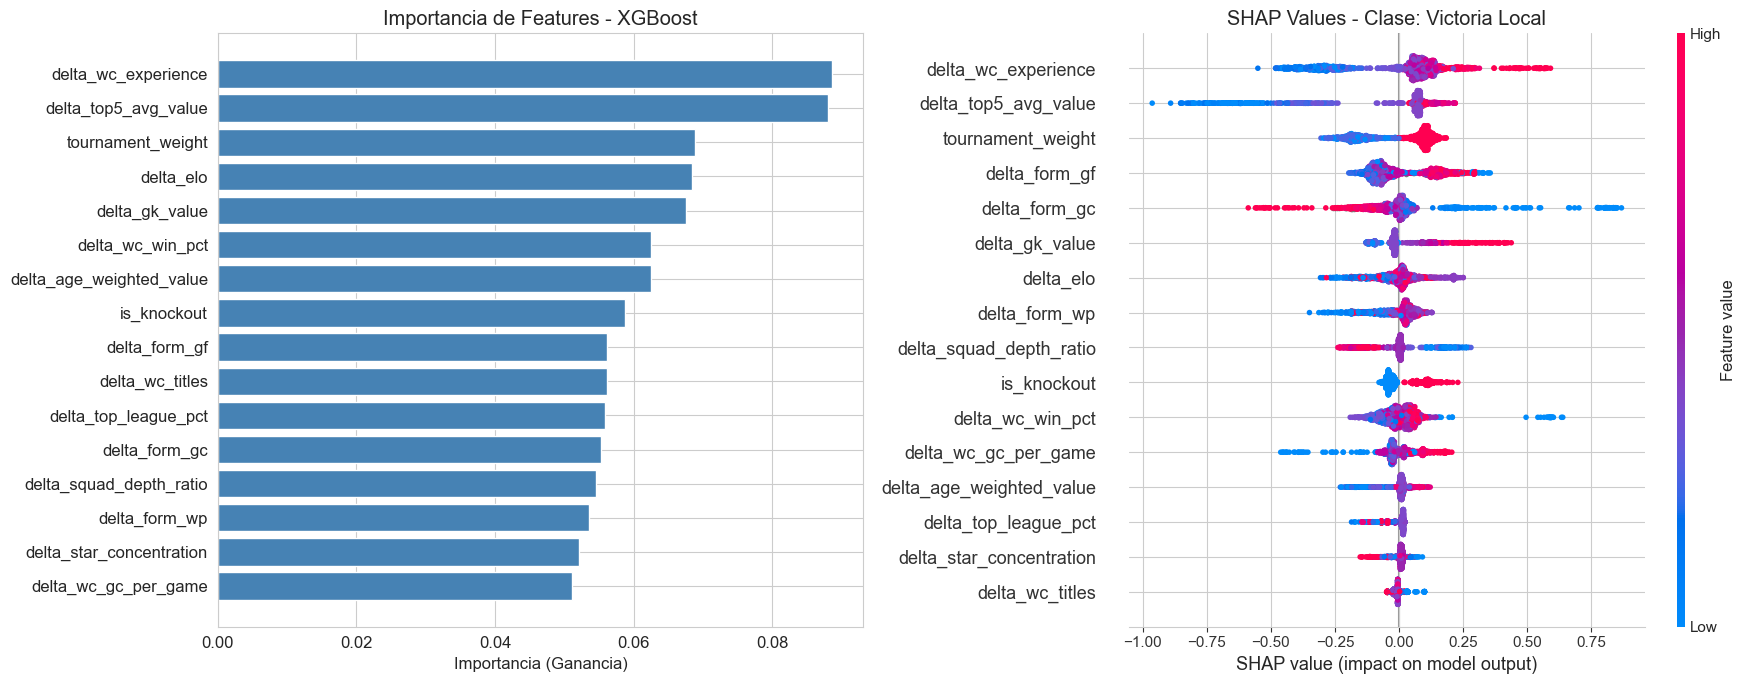

In [16]:
# --- 7.2 Importancia de features ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Ganancia XGBoost
importance = final_model.feature_importances_
sorted_idx = np.argsort(importance)
axes[0].barh([feature_cols[i] for i in sorted_idx], importance[sorted_idx], color='steelblue')
axes[0].set_xlabel('Importancia (Ganancia)')
axes[0].set_title('Importancia de Features - XGBoost')

# SHAP values (manejar formato multi-clase)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

# Para multi-clase, shap_values puede ser lista de arrays o array 3D
plt.sca(axes[1])
if isinstance(shap_values, list):
    # Lista de arrays: uno por clase
    shap.summary_plot(shap_values[2], X, feature_names=feature_cols, show=False, plot_size=None)
elif shap_values.ndim == 3:
    # Array 3D: (samples, features, classes)
    shap.summary_plot(shap_values[:, :, 2], X, feature_names=feature_cols, show=False, plot_size=None)
else:
    # 2D: usar directamente
    shap.summary_plot(shap_values, X, feature_names=feature_cols, show=False, plot_size=None)
axes[1].set_title('SHAP Values - Clase: Victoria Local')

plt.tight_layout()
plt.show()

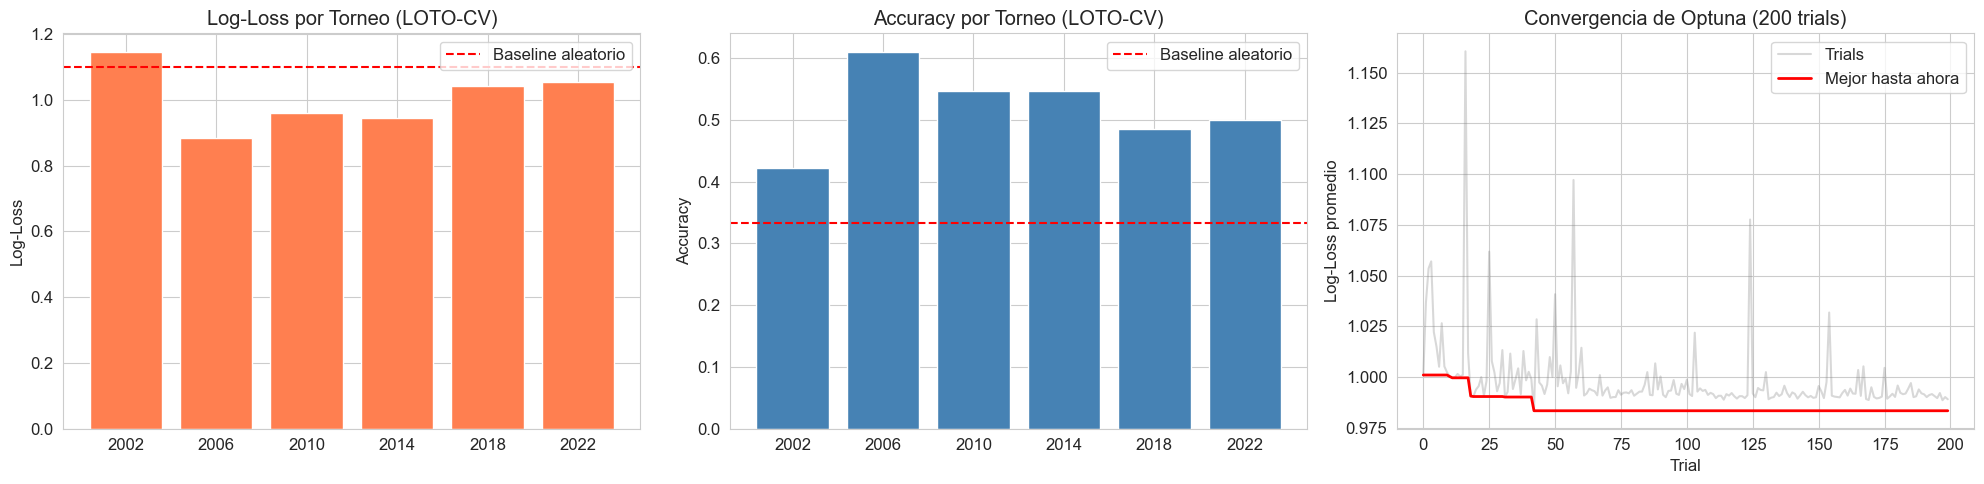

,test_year,n_train,n_test,log_loss,accuracy,actual_winner
0,2002,748,64,1.144876,0.421875,BRA
1,2006,869,64,0.884513,0.609375,ITA
2,2010,990,64,0.960810,0.546875,ESP
3,2014,1111,64,0.943655,0.546875,GER
4,2018,1284,64,1.042588,0.484375,FRA
5,2022,1449,64,1.055474,0.500000,ARG


In [17]:
# --- 7.3 Resultados LOTO-CV + visualización Optuna ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Log-loss por torneo
axes[0].bar(cv_df['test_year'].astype(str), cv_df['log_loss'], color='coral')
axes[0].axhline(y=1.099, color='red', linestyle='--', label='Baseline aleatorio')
axes[0].set_ylabel('Log-Loss')
axes[0].set_title('Log-Loss por Torneo (LOTO-CV)')
axes[0].legend()

# Accuracy por torneo
axes[1].bar(cv_df['test_year'].astype(str), cv_df['accuracy'], color='steelblue')
axes[1].axhline(y=0.333, color='red', linestyle='--', label='Baseline aleatorio')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy por Torneo (LOTO-CV)')
axes[1].legend()

# Convergencia de Optuna
trial_values = [t.value for t in study.trials]
best_so_far = [min(trial_values[:i+1]) for i in range(len(trial_values))]
axes[2].plot(range(len(trial_values)), trial_values, alpha=0.3, color='gray', label='Trials')
axes[2].plot(range(len(best_so_far)), best_so_far, color='red', linewidth=2, label='Mejor hasta ahora')
axes[2].set_xlabel('Trial')
axes[2].set_ylabel('Log-Loss promedio')
axes[2].set_title('Convergencia de Optuna (200 trials)')
axes[2].legend()

plt.tight_layout()
plt.show()

cv_df

## 8. Simulación Monte Carlo del Torneo 2026

Simulamos el torneo completo **50,000 veces** usando las probabilidades del modelo XGBoost optimizado.

Para la simulación 2026, cada equipo tiene features derivadas de:
- **Elo actual** (calculado a partir de TODOS los partidos históricos)
- **Forma 2026** (blend de eliminatorias 2026 + historial reciente de torneos oficiales)
- **Historial mundialista acumulado**

In [18]:
# --- 8.1 Preparar grupos y features de los 48 equipos ---

teams_2026 = momios['country_code'].tolist()
groups_2026 = {}
for letter in momios['group_letter'].unique():
    groups_2026[letter] = momios[momios['group_letter'] == letter]['country_code'].tolist()

print(f'Equipos: {len(teams_2026)}')
print(f'Grupos: {len(groups_2026)}')
for g, teams in sorted(groups_2026.items()):
    print(f'  Grupo {g}: {teams}')

Equipos: 48
Grupos: 12
  Grupo A: ['MEX', 'CZE', 'KOR', 'RSA']
  Grupo B: ['SUI', 'CAN', 'BIH', 'QAT']
  Grupo C: ['BRA', 'MAR', 'SCO', 'HAI']
  Grupo D: ['USA', 'TUR', 'PAR', 'AUS']
  Grupo E: ['GER', 'ECU', 'CIV', 'CUW']
  Grupo F: ['NED', 'JPN', 'SWE', 'TUN']
  Grupo G: ['BEL', 'EGY', 'IRN', 'NZL']
  Grupo H: ['ESP', 'URU', 'KSA', 'CPV']
  Grupo I: ['FRA', 'NOR', 'SEN', 'IRQ']
  Grupo J: ['ARG', 'AUT', 'ALG', 'JOR']
  Grupo K: ['POR', 'COL', 'COD', 'UZB']
  Grupo L: ['ENG', 'CRO', 'GHA', 'PAN']


In [19]:
# --- 8.2 Features de cada equipo para 2026 ---

# Cargar historial mundialista para experiencia
try:
    hist_wc = pd.read_csv('Data/WorldCupHistory/historial_mundialista.csv')
    hist_wc_dict = dict(zip(hist_wc['country_code'], hist_wc['pj']))
except:
    hist_wc_dict = {}

# Eliminatorias 2026 agregadas: las usamos como proxy de forma ACTUAL.
try:
    qual_agg = pd.read_csv('Data/Eliminatorias/eliminatorias_conjuntas.csv')
    qual_lookup = qual_agg.set_index('country_code')
except:
    qual_lookup = pd.DataFrame().set_index(pd.Index([]))

team_features_2026 = {}

for team_code in teams_2026:
    lookup_code = code_alias.get(team_code, team_code)
    master_row = master[master['country_code'] == lookup_code]
    
    if len(master_row) == 0:
        print(f'WARN: {team_code} no encontrado en master dataset')
        continue
    
    mr = master_row.iloc[0]
    
    # Elo actual (del cálculo sobre todos los partidos)
    elo = elo_final.get(team_code, ELO_INIT)
    
    # Forma 2026: blend de eliminatorias (más actual) + torneos oficiales recientes como prior.
    qual_form_wp = float(np.clip(mr['qual_points_per_game'] / 3.0, 0.0, 1.0))
    if lookup_code in qual_lookup.index and qual_lookup.loc[lookup_code, 'pj'] > 0:
        qual_form_wp = float(qual_lookup.loc[lookup_code, 'win_pct'])
    qual_form_gf = float(mr['qual_gf_per_game'])
    qual_form_gc = float(mr['qual_gc_per_game'])

    recent = team_histories.get(team_code, [])[-10:]
    if len(recent) >= 3:
        major_wp = sum(1 for _, o, _, _ in recent if o == 'W') / len(recent)
        major_gf = float(np.mean([gf for _, _, gf, _ in recent]))
        major_gc = float(np.mean([gc for _, _, _, gc in recent]))
    else:
        major_wp, major_gf, major_gc = qual_form_wp, qual_form_gf, qual_form_gc

    form_wp = 0.70 * qual_form_wp + 0.30 * major_wp
    form_gf = 0.70 * qual_form_gf + 0.30 * major_gf
    form_gc = 0.70 * qual_form_gc + 0.30 * major_gc
    
    team_features_2026[team_code] = {
        'elo': elo,
        'form_wp': form_wp,
        'form_gf': form_gf,
        'form_gc': form_gc,
        'ranking': mr['ranking_2026'],
        'wc_win_pct': mr['wc_win_pct'],
        'wc_gc_per_game': mr['wc_gc_per_game'],
        'wc_titles': mr['wc_titles'],
        'wc_experience': hist_wc_dict.get(lookup_code, 0 if mr['wc_debut_flag'] == 1 else 10),
        # market_value removido (temporalmente inválido para training)
    }
    
    # Agregar features de jugadores 2026
    pf = get_player_features(team_code, 2025)  # 2025 es el año más reciente disponible
    team_features_2026[team_code].update({
        'star_concentration': pf['star_concentration'],
        'top5_avg_value': pf['top5_avg_value'],
        'gk_value': pf['gk_value'],
        'squad_depth_ratio': pf['squad_depth_ratio'],
        'age_weighted_value': pf['age_weighted_value'],
        'top_league_pct': pf['top_league_pct'],
    })

print(f'Features preparadas para {len(team_features_2026)} equipos.\n')
print(f'{"Equipo":>6} {"Elo":>6} {"Forma":>6} {"Ranking":>7} {"WC%":>5} {"Títulos":>8}')
print('-' * 45)
for team in sorted(team_features_2026.keys(), key=lambda t: -team_features_2026[t]['elo'])[:15]:
    f = team_features_2026[team]
    print(f'{team:>6} {f["elo"]:>6.0f} {f["form_wp"]:>6.2f} {f["ranking"]:>7.0f} {f["wc_win_pct"]:>5.2f} {f["wc_titles"]:>8.0f}')

Features preparadas para 48 equipos.

Equipo    Elo  Forma Ranking   WC%  Títulos
---------------------------------------------
   FRA   1720   0.73       3  0.53        2
   ESP   1714   0.76       1  0.46        1
   ARG   1712   0.65       2  0.53        3
   NED   1705   0.67       7  0.55        0
   BRA   1686   0.49       5  0.67        5
   GER   1672   0.70      10  0.61        4
   ENG   1627   0.82       4  0.43        1
   BEL   1609   0.56       9  0.41        0
   CRO   1603   0.67      11  0.43        0
   COL   1603   0.39      14  0.41        0
   URU   1600   0.39      17  0.42        2
   POR   1592   0.62       6  0.49        0
   SUI   1570   0.59      18  0.34        0
   SWE   1558   0.15      42  0.37        0
   MEX   1535   0.59      16  0.28        0


In [20]:
# --- 8.3 Precomputar probabilidades (order-invariant para cancha neutral) ---
# FIX: En mundiales la cancha es neutral. Promediamos las probabilidades
# de ambas orientaciones (A vs B) y (B vs A) para eliminar sesgo de orden.
# FIX: delta_ranking removido para mantener consistencia temporal con training.

def make_match_features(team_a, team_b, is_knockout=0):
    fa = team_features_2026[team_a]
    fb = team_features_2026[team_b]
    return np.array([
        fa['elo'] - fb['elo'],
        fa['form_wp'] - fb['form_wp'],
        fa['form_gf'] - fb['form_gf'],
        fa['form_gc'] - fb['form_gc'],
        fa['wc_win_pct'] - fb['wc_win_pct'],
        fa['wc_gc_per_game'] - fb['wc_gc_per_game'],
        fa['wc_titles'] - fb['wc_titles'],
        fa['wc_experience'] - fb['wc_experience'],
        is_knockout,
        1.0,
        fa.get('star_concentration', 0) - fb.get('star_concentration', 0),
        fa.get('top5_avg_value', 0) - fb.get('top5_avg_value', 0),
        fa.get('gk_value', 0) - fb.get('gk_value', 0),
        fa.get('squad_depth_ratio', 0) - fb.get('squad_depth_ratio', 0),
        fa.get('age_weighted_value', 0) - fb.get('age_weighted_value', 0),
        fa.get('top_league_pct', 0) - fb.get('top_league_pct', 0),
    ]).reshape(1, -1)

pairs = [(a, b) for a in teams_2026 for b in teams_2026 if a != b]

X_group = np.vstack([make_match_features(a, b, 0) for a, b in pairs])
X_ko = np.vstack([make_match_features(a, b, 1) for a, b in pairs])

gp_raw = final_model.predict_proba(X_group)
kp_raw = final_model.predict_proba(X_ko)

raw_group = {}
raw_ko = {}
for i, (a, b) in enumerate(pairs):
    raw_group[(a, b)] = gp_raw[i]
    raw_ko[(a, b)] = kp_raw[i]

# Promediar ambas orientaciones para cancha neutral
# P(A,B) orientación A=home: [P(B wins), P(draw), P(A wins)]
# P(B,A) orientación B=home: [P(A wins), P(draw), P(B wins)]
# Promedio simétrico: P(A wins) = (raw[A,B][2] + raw[B,A][0]) / 2

group_proba_cache = {}
knockout_proba_cache = {}

for a in teams_2026:
    for b in teams_2026:
        if a == b: continue
        # Para (a, b): a es "home" conceptual
        # raw[(a,b)] = [P(b_wins), P(draw), P(a_wins)]
        # raw[(b,a)] = [P(a_wins), P(draw), P(b_wins)]
        p_ab = raw_group[(a, b)]  # [away_win, draw, home_win] = [b_win, draw, a_win]
        p_ba = raw_group[(b, a)]  # [a_win, draw, b_win]
        
        avg_a_win = (p_ab[2] + p_ba[0]) / 2
        avg_draw  = (p_ab[1] + p_ba[1]) / 2
        avg_b_win = (p_ab[0] + p_ba[2]) / 2
        total = avg_a_win + avg_draw + avg_b_win
        group_proba_cache[(a, b)] = np.array([avg_b_win/total, avg_draw/total, avg_a_win/total])
        
        p_ab_k = raw_ko[(a, b)]
        p_ba_k = raw_ko[(b, a)]
        avg_a_win_k = (p_ab_k[2] + p_ba_k[0]) / 2
        avg_draw_k  = (p_ab_k[1] + p_ba_k[1]) / 2
        avg_b_win_k = (p_ab_k[0] + p_ba_k[2]) / 2
        total_k = avg_a_win_k + avg_draw_k + avg_b_win_k
        knockout_proba_cache[(a, b)] = np.array([avg_b_win_k/total_k, avg_draw_k/total_k, avg_a_win_k/total_k])

# Verificar simetría
p_ab = group_proba_cache[('ARG', 'ENG')]
p_ba = group_proba_cache[('ENG', 'ARG')]
print(f'Verificación de simetría (ARG vs ENG):')
print(f'  cache[(ARG,ENG)]: P(ENG)={p_ab[0]:.4f}, P(draw)={p_ab[1]:.4f}, P(ARG)={p_ab[2]:.4f}')
print(f'  cache[(ENG,ARG)]: P(ARG)={p_ba[0]:.4f}, P(draw)={p_ba[1]:.4f}, P(ENG)={p_ba[2]:.4f}')
print(f'  P(ARG wins) consistente: {abs(p_ab[2] - p_ba[0]) < 1e-6}')
print(f'\nProbabilidades precomputadas para {len(group_proba_cache)} pares (order-invariant).')

Verificación de simetría (ARG vs ENG):
  cache[(ARG,ENG)]: P(ENG)=0.2594, P(draw)=0.4348, P(ARG)=0.3058
  cache[(ENG,ARG)]: P(ARG)=0.3058, P(draw)=0.4348, P(ENG)=0.2594
  P(ARG wins) consistente: True

Probabilidades precomputadas para 2256 pares (order-invariant).


In [21]:
# --- 8.4 Funciones de simulación ---

def sample_goals(outcome, rng):
    if outcome == 2:
        gf = max(1, rng.poisson(1.8))
        gc = min(gf - 1, max(0, rng.poisson(0.7)))
    elif outcome == 0:
        gc = max(1, rng.poisson(1.8))
        gf = min(gc - 1, max(0, rng.poisson(0.7)))
    else:
        g = max(0, rng.poisson(0.9))
        gf, gc = g, g
    return gf, gc

def simulate_group(group_teams, rng):
    standings = {t: {'pts': 0, 'gd': 0, 'gf': 0} for t in group_teams}
    for i in range(len(group_teams)):
        for j in range(i + 1, len(group_teams)):
            home, away = group_teams[i], group_teams[j]
            proba = group_proba_cache[(home, away)]
            outcome = rng.choice([0, 1, 2], p=proba)
            gf, gc = sample_goals(outcome, rng)
            if outcome == 2:
                standings[home]['pts'] += 3
            elif outcome == 0:
                standings[away]['pts'] += 3
            else:
                standings[home]['pts'] += 1; standings[away]['pts'] += 1
            standings[home]['gd'] += gf - gc; standings[home]['gf'] += gf
            standings[away]['gd'] += gc - gf; standings[away]['gf'] += gc
    sorted_teams = sorted(group_teams, key=lambda t: (
        standings[t]['pts'], standings[t]['gd'], standings[t]['gf']), reverse=True)
    return sorted_teams, standings

def get_advancing_teams(group_results):
    top2 = []; thirds = []
    for gl in sorted(group_results.keys()):
        sorted_teams, standings = group_results[gl]
        top2.extend(sorted_teams[:2])
        if len(sorted_teams) >= 3:
            thirds.append((sorted_teams[2], standings[sorted_teams[2]], gl))
    thirds.sort(key=lambda x: (x[1]['pts'], x[1]['gd'], x[1]['gf']), reverse=True)
    best_thirds = [(t[0], t[2]) for t in thirds[:8]]
    return top2, best_thirds

def simulate_knockout_match(team_a, team_b, rng):
    proba = knockout_proba_cache[(team_a, team_b)]
    outcome = rng.choice([0, 1, 2], p=proba)
    if outcome == 2: return team_a
    elif outcome == 0: return team_b
    else:
        p_a = proba[2] / (proba[0] + proba[2]) if (proba[0] + proba[2]) > 0 else 0.5
        return team_a if rng.random() < p_a else team_b

def build_knockout_bracket(top2, best_thirds):
    """
    Construir R32 con slots fijos del formato FIFA 2026.
    Los ocho mejores terceros se asignan a los ganadores elegibles mediante
    matching determinístico usando los grupos permitidos por slot.
    """
    group_letters = sorted(groups_2026.keys())
    winners = {group_letters[i]: top2[i*2] for i in range(12)}
    runners = {group_letters[i]: top2[i*2+1] for i in range(12)}
    thirds_by_group = {group: team for team, group in best_thirds}
    qualified_third_groups = set(thirds_by_group)

    # Slots de ganadores que enfrentan terceros, con sus grupos permitidos.
    third_slot_allowed = {
        'A': {'C', 'E', 'F', 'H', 'I'},
        'B': {'E', 'F', 'G', 'I', 'J'},
        'D': {'B', 'E', 'F', 'I', 'J'},
        'E': {'A', 'B', 'C', 'D', 'F'},
        'G': {'A', 'E', 'H', 'I', 'J'},
        'I': {'C', 'D', 'F', 'G', 'H'},
        'K': {'D', 'E', 'I', 'J', 'L'},
        'L': {'E', 'H', 'I', 'J', 'K'},
    }

    slot_candidates = {
        slot: sorted(groups & qualified_third_groups)
        for slot, groups in third_slot_allowed.items()
    }
    if any(len(cands) == 0 for cands in slot_candidates.values()):
        raise ValueError('No hay candidatos válidos para uno de los slots de terceros.')

    slot_order = sorted(slot_candidates, key=lambda slot: (len(slot_candidates[slot]), slot))
    slot_assignment = {}
    used_groups = set()

    def backtrack(slot_idx=0):
        if slot_idx == len(slot_order):
            return True
        slot = slot_order[slot_idx]
        for group in slot_candidates[slot]:
            if group in used_groups:
                continue
            used_groups.add(group)
            slot_assignment[slot] = group
            feasible = True
            for other in slot_order[slot_idx + 1:]:
                if not any(candidate not in used_groups for candidate in slot_candidates[other]):
                    feasible = False
                    break
            if feasible and backtrack(slot_idx + 1):
                return True
            used_groups.remove(group)
            slot_assignment.pop(slot, None)
        return False

    if not backtrack():
        raise ValueError(f'No se pudo asignar un bracket válido para terceros: {sorted(qualified_third_groups)}')

    pair_templates = [
        ('2A', '2B'),
        ('1C', '2F'),
        ('1E', ('3slot', 'E')),
        ('1F', '2C'),
        ('2E', '2I'),
        ('1I', ('3slot', 'I')),
        ('1A', ('3slot', 'A')),
        ('1L', ('3slot', 'L')),
        ('1G', ('3slot', 'G')),
        ('1D', ('3slot', 'D')),
        ('1H', '2J'),
        ('2K', '2L'),
        ('1B', ('3slot', 'B')),
        ('2D', '2G'),
        ('1J', '2H'),
        ('1K', ('3slot', 'K')),
    ]

    def resolve_slot(slot):
        if isinstance(slot, tuple) and slot[0] == '3slot':
            group = slot_assignment[slot[1]]
            return thirds_by_group[group]
        place, group = slot[0], slot[1]
        return winners[group] if place == '1' else runners[group]

    r32 = [(resolve_slot(a), resolve_slot(b)) for a, b in pair_templates]
    flat_teams = [team for match in r32 for team in match]
    if len(flat_teams) != 32 or len(set(flat_teams)) != 32:
        raise ValueError('El bracket R32 contiene equipos duplicados o incompletos.')
    return r32

def simulate_knockout_rounds(r32_matches, rng):
    current = r32_matches
    round_results = defaultdict(set)
    
    while len(current) > 1:
        next_winners = []
        for a, b in current:
            winner = simulate_knockout_match(a, b, rng)
            next_winners.append(winner)
        current = [(next_winners[i], next_winners[i+1]) for i in range(0, len(next_winners), 2)]
        if len(current) == 2:
            for a, b in current:
                round_results['semifinal'].add(a)
                round_results['semifinal'].add(b)
        elif len(current) == 1:
            round_results['final'].add(current[0][0])
            round_results['final'].add(current[0][1])
    
    champion = simulate_knockout_match(current[0][0], current[0][1], rng)
    finalist = current[0][1] if champion == current[0][0] else current[0][0]
    return champion, finalist, round_results

print('Funciones de simulación definidas (con bracket FIFA 2026).')

Funciones de simulación definidas (con bracket FIFA 2026).


In [22]:
# --- 8.5 Ejecutar simulación Monte Carlo (50,000 iteraciones) ---

N_SIMULATIONS = 50_000

champion_counts = defaultdict(int)
finalist_counts = defaultdict(int)
semifinal_counts = defaultdict(int)
group_exit_counts = defaultdict(int)

print(f'Ejecutando {N_SIMULATIONS:,} simulaciones Monte Carlo...')
print('Esto tomará varios minutos.\n')

valid_sims = 0
for sim in range(N_SIMULATIONS):
    if sim % 10_000 == 0 and sim > 0:
        leader = max(champion_counts, key=champion_counts.get)
        leader_pct = champion_counts[leader] / valid_sims * 100
        print(f'  Simulación {sim:,}/{N_SIMULATIONS:,} — Líder actual: {leader} ({leader_pct:.1f}%)')
    
    # 1. Fase de grupos
    group_results = {}
    for gl, teams in groups_2026.items():
        sorted_teams, standings = simulate_group(teams, rng)
        group_results[gl] = (sorted_teams, standings)
    
    # 2. Determinar 32 que avanzan
    top2, best_thirds = get_advancing_teams(group_results)
    
    # 3. Bracket de eliminación directa
    r32_matches = build_knockout_bracket(top2, best_thirds)
    advancing = set(top2 + [team for team, _ in best_thirds])
    
    for team in teams_2026:
        if team not in advancing:
            group_exit_counts[team] += 1
    
    champion, finalist, round_results = simulate_knockout_rounds(r32_matches, rng)
    champion_counts[champion] += 1
    finalist_counts[finalist] += 1
    for team in round_results.get('semifinal', set()):
        semifinal_counts[team] += 1
    
    valid_sims += 1

print(f'\n✅ Simulación completada: {valid_sims:,} simulaciones válidas.')

Ejecutando 50,000 simulaciones Monte Carlo...
Esto tomará varios minutos.



  Simulación 10,000/50,000 — Líder actual: BRA (23.3%)


  Simulación 20,000/50,000 — Líder actual: BRA (23.3%)


  Simulación 30,000/50,000 — Líder actual: BRA (22.9%)


  Simulación 40,000/50,000 — Líder actual: BRA (23.1%)



✅ Simulación completada: 50,000 simulaciones válidas.


In [23]:
# --- 8.6 Calcular y mostrar probabilidades ---

results = []
for team in teams_2026:
    results.append({
        'country_code': team,
        'champion_pct': champion_counts[team] / valid_sims * 100 if valid_sims > 0 else 0,
        'finalist_pct': (champion_counts[team] + finalist_counts[team]) / valid_sims * 100 if valid_sims > 0 else 0,
        'semifinal_pct': semifinal_counts[team] / valid_sims * 100 if valid_sims > 0 else 0,
        'group_exit_pct': group_exit_counts[team] / valid_sims * 100 if valid_sims > 0 else 0,
    })

results_df = pd.DataFrame(results).sort_values('champion_pct', ascending=False).reset_index(drop=True)
results_df.index += 1

# Agregar momios y Elo
momios_dict = dict(zip(momios['country_code'], momios['champion_prob'] * 100))
results_df['momios_pct'] = results_df['country_code'].map(momios_dict)
results_df['elo'] = results_df['country_code'].map(lambda t: team_features_2026.get(t, {}).get('elo', 0))

print('\n' + '=' * 90)
print('PROBABILIDADES DE CAMPEON - COPA DEL MUNDO 2026')
print('=' * 90)
print(f'{"Rank":>4} {"Equipo":>8} {"Modelo%":>9} {"Momios%":>9} {"Elo":>6} {"Final%":>8} {"Semi%":>7} {"Elim.Grupo%":>12}')
print('-' * 90)
for _, row in results_df.head(25).iterrows():
    print(f'{row.name:>4} {row["country_code"]:>8} {row["champion_pct"]:>8.2f}% {row["momios_pct"]:>8.2f}% '
          f'{row["elo"]:>6.0f} {row["finalist_pct"]:>7.2f}% {row["semifinal_pct"]:>6.2f}% '
          f'{row["group_exit_pct"]:>11.2f}%')


PROBABILIDADES DE CAMPEON - COPA DEL MUNDO 2026
Rank   Equipo   Modelo%   Momios%    Elo   Final%   Semi%  Elim.Grupo%
------------------------------------------------------------------------------------------
   1      BRA    22.96%     8.82%   1686   32.53%  46.12%        9.66%
   2      ESP    17.41%    14.44%   1714   29.48%  41.69%        6.52%
   3      ENG    17.01%    11.34%   1627   26.71%  41.29%        6.94%
   4      ARG    10.36%     8.82%   1712   25.05%  39.48%        4.33%
   5      GER     8.40%     6.11%   1672   14.60%  27.09%       10.10%
   6      FRA     7.59%    13.23%   1720   14.39%  27.83%        6.86%
   7      URU     2.96%     1.19%   1600    8.82%  21.69%        8.40%
   8      BEL     2.39%     2.34%   1609    8.30%  20.47%        5.26%
   9      NED     1.68%     3.78%   1705    4.80%  13.41%       10.32%
  10      NOR     1.51%     3.05%   1512    4.78%  12.81%       15.11%
  11      POR     1.36%     7.94%   1592    5.09%  13.25%        7.46%
  12    

In [24]:
# --- Guardar resultados ---
results_df.to_csv('Data/simulation_results.csv', index=False)
print('Resultados guardados en Data/simulation_results.csv')

Resultados guardados en Data/simulation_results.csv


## 9. Visualización de Resultados

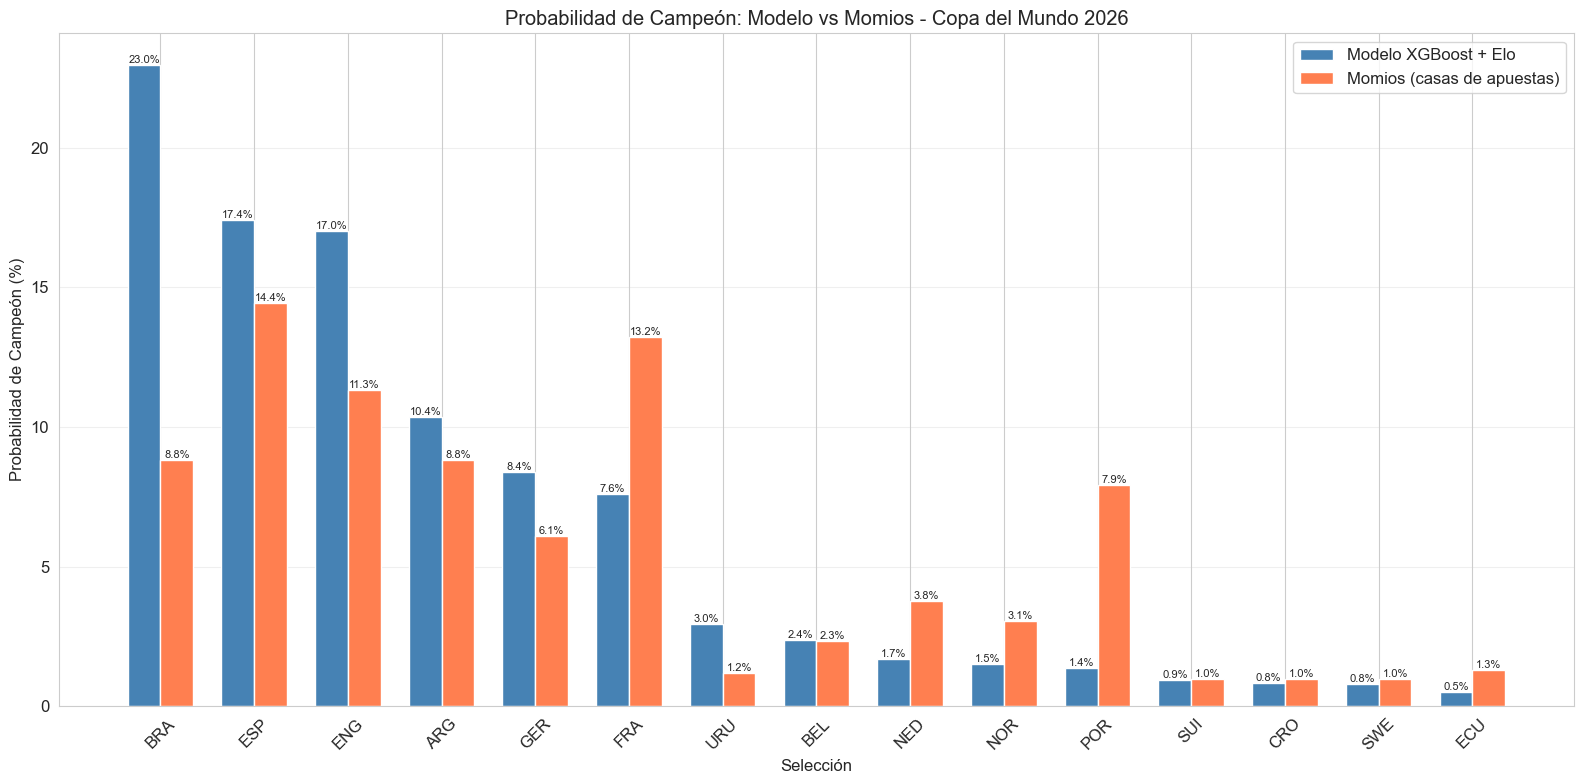

In [25]:
# --- 9.1 Top 15: Modelo vs Momios ---
top15 = results_df.head(15)

fig, ax = plt.subplots(figsize=(16, 8))
x = np.arange(len(top15))
width = 0.35

bars1 = ax.bar(x - width/2, top15['champion_pct'], width, label='Modelo XGBoost + Elo', color='steelblue')
bars2 = ax.bar(x + width/2, top15['momios_pct'], width, label='Momios (casas de apuestas)', color='coral')

ax.set_xlabel('Selección')
ax.set_ylabel('Probabilidad de Campeón (%)')
ax.set_title('Probabilidad de Campeón: Modelo vs Momios - Copa del Mundo 2026')
ax.set_xticks(x)
ax.set_xticklabels(top15['country_code'], rotation=45, fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Agregar valores sobre las barras
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

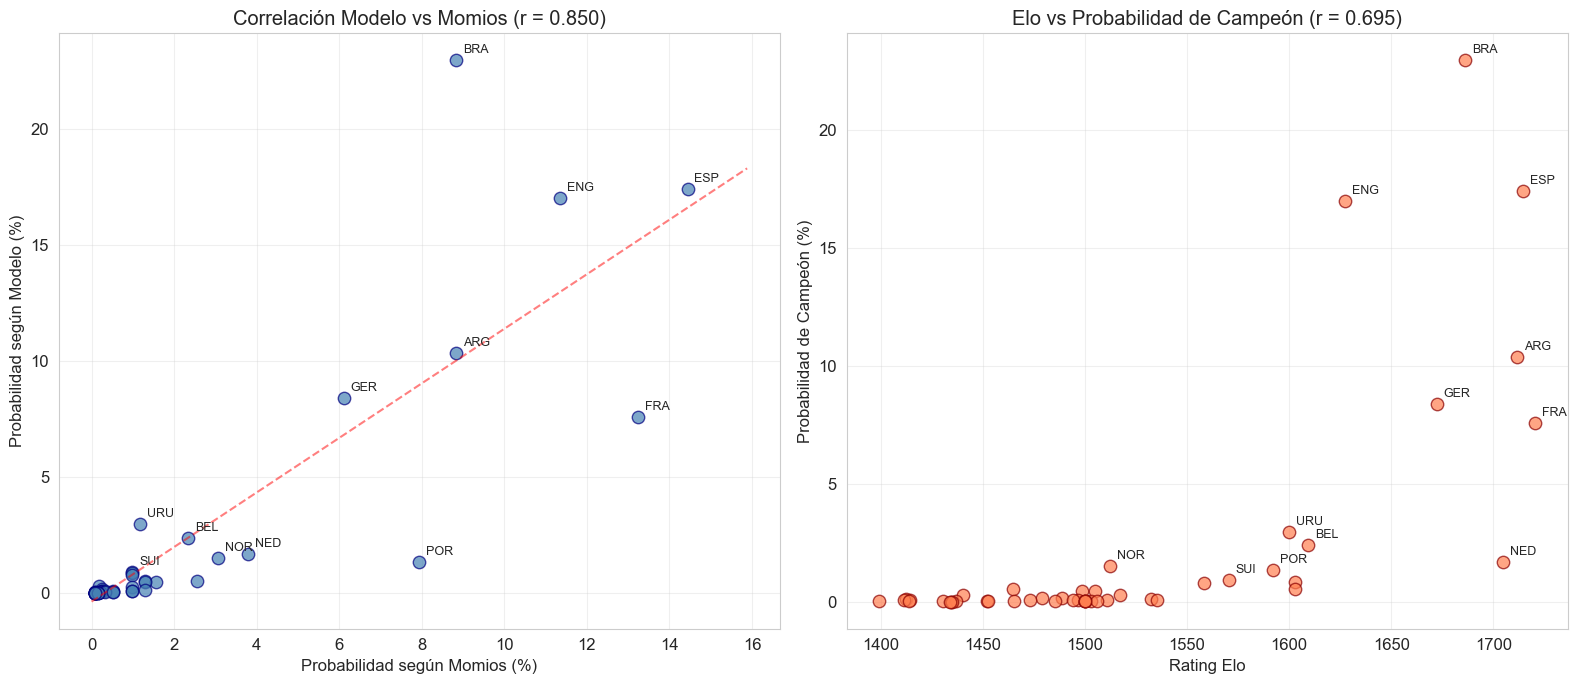

In [26]:
# --- 9.2 Correlación Modelo vs Momios ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter plot
ax = axes[0]
ax.scatter(results_df['momios_pct'], results_df['champion_pct'],
           s=80, alpha=0.7, color='steelblue', edgecolors='navy')

for _, row in results_df.head(12).iterrows():
    ax.annotate(row['country_code'], (row['momios_pct'], row['champion_pct']),
                textcoords='offset points', xytext=(5, 5), fontsize=9)

from numpy.polynomial.polynomial import polyfit
b, m = polyfit(results_df['momios_pct'], results_df['champion_pct'], 1)
x_line = np.linspace(0, results_df['momios_pct'].max() * 1.1, 100)
ax.plot(x_line, b + m * x_line, 'r--', alpha=0.5)

corr = results_df['momios_pct'].corr(results_df['champion_pct'])
ax.set_xlabel('Probabilidad según Momios (%)')
ax.set_ylabel('Probabilidad según Modelo (%)')
ax.set_title(f'Correlación Modelo vs Momios (r = {corr:.3f})')
ax.grid(alpha=0.3)

# Elo vs probabilidad de campeón
ax2 = axes[1]
ax2.scatter(results_df['elo'], results_df['champion_pct'],
            s=80, alpha=0.7, color='coral', edgecolors='darkred')

for _, row in results_df.head(12).iterrows():
    ax2.annotate(row['country_code'], (row['elo'], row['champion_pct']),
                 textcoords='offset points', xytext=(5, 5), fontsize=9)

corr_elo = results_df['elo'].corr(results_df['champion_pct'])
ax2.set_xlabel('Rating Elo')
ax2.set_ylabel('Probabilidad de Campeón (%)')
ax2.set_title(f'Elo vs Probabilidad de Campeón (r = {corr_elo:.3f})')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

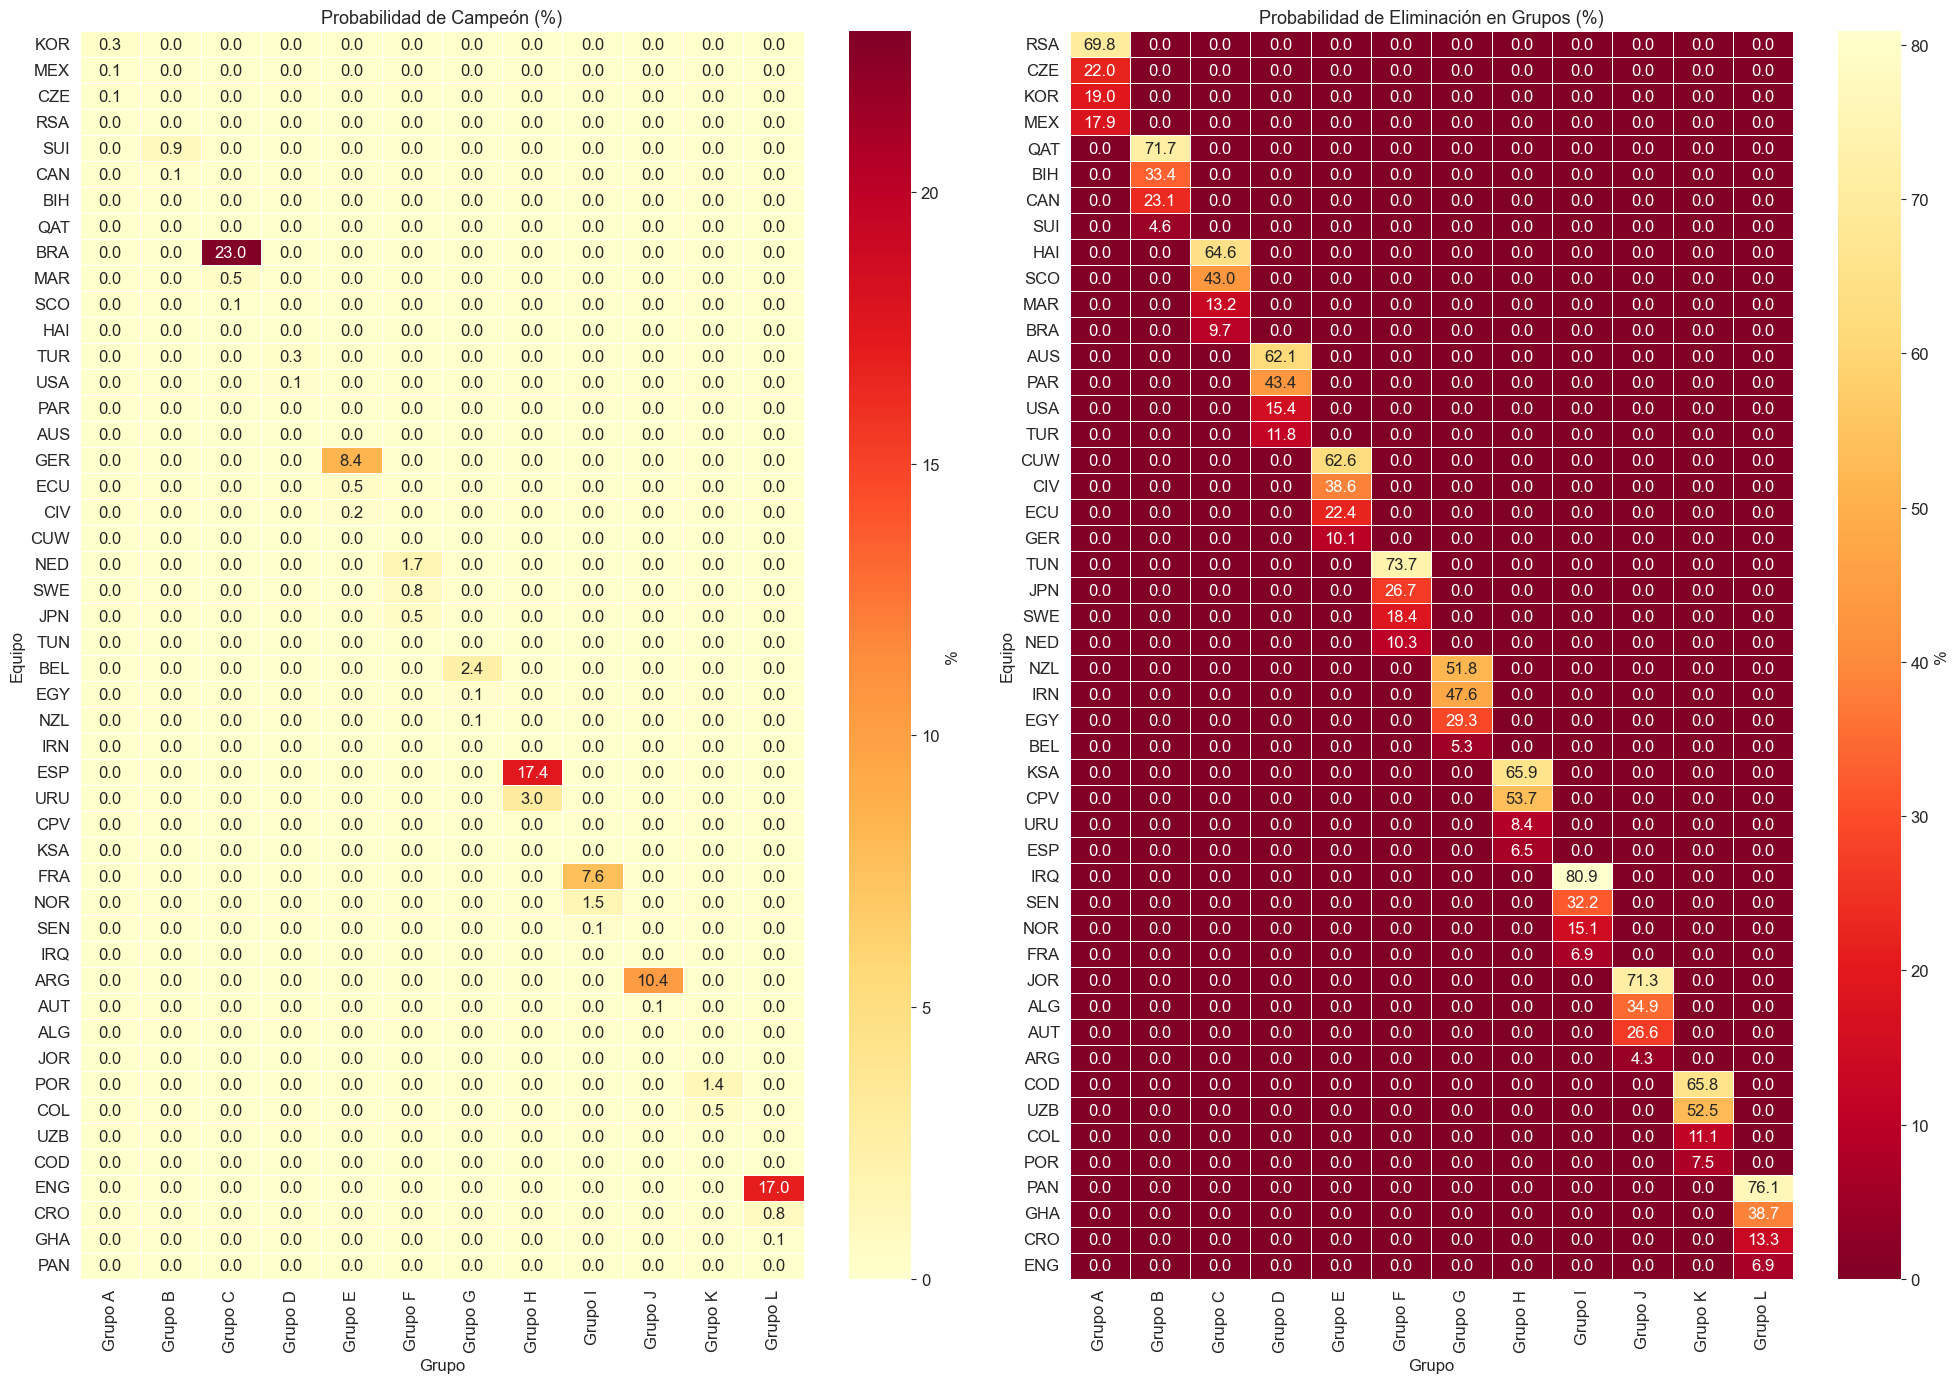

In [27]:
# --- 9.3 Heatmap de probabilidades por grupo ---

group_data = []
for gl in sorted(groups_2026.keys()):
    for team in groups_2026[gl]:
        row = results_df[results_df['country_code'] == team]
        if len(row) > 0:
            group_data.append({
                'Grupo': f'Grupo {gl}',
                'Equipo': team,
                'Campeon_pct': row.iloc[0]['champion_pct'],
                'Eliminado_pct': row.iloc[0]['group_exit_pct'],
            })

group_df = pd.DataFrame(group_data)

fig, axes = plt.subplots(1, 2, figsize=(20, 14))

for ax_idx, (col, title, cmap) in enumerate([
    ('Campeon_pct', 'Probabilidad de Campeón (%)', 'YlOrRd'),
    ('Eliminado_pct', 'Probabilidad de Eliminación en Grupos (%)', 'YlOrRd_r'),
]):
    pivot = group_df.pivot(index='Equipo', columns='Grupo', values=col).fillna(0)
    # Ordenar por grupo y luego por valor
    team_order = group_df.sort_values(['Grupo', col], ascending=[True, False])['Equipo'].tolist()
    pivot = pivot.reindex(team_order)
    
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap, ax=axes[ax_idx],
                cbar_kws={'label': '%'}, linewidths=0.5)
    axes[ax_idx].set_title(title, fontsize=13)

plt.tight_layout()
plt.show()

In [28]:
# --- 9.4 Resumen final ---
print('\n' + '=' * 70)
print('RESUMEN DEL MODELO PREDICTIVO - COPA DEL MUNDO 2026')
print('=' * 70)
print(f'\n--- Datos ---')
print(f'Partidos de entrenamiento: {len(train_df)} (WC + Euro + Copa América)')
print(f'Features utilizadas: {len(feature_cols)}')
print(f'Feature principal: Elo dinámico (K={K_FACTOR})')
print(f'\n--- Modelo ---')
print(f'Algoritmo: XGBoost (multi:softprob, 3 clases)')
print(f'Optimización: Optuna ({len(study.trials)} trials)')
print(f'Mejores hiperparámetros: {study.best_params}')
print(f'\n--- Validación (LOTO-CV) ---')
print(f'Log-loss promedio: {cv_df["log_loss"].mean():.4f} (baseline: 1.099)')
print(f'Accuracy promedio: {cv_df["accuracy"].mean():.3f} (baseline: 0.333)')
print(f'\n--- Simulación ---')
print(f'Simulaciones Monte Carlo: {N_SIMULATIONS:,}')
print(f'Correlación modelo vs momios: {corr:.3f}')
print(f'\n--- Top 10 Favoritos ---')
for _, row in results_df.head(10).iterrows():
    print(f'  {row.name:2d}. {row["country_code"]:>5} — {row["champion_pct"]:.2f}% '
          f'(Elo: {row["elo"]:.0f}, momios: {row["momios_pct"]:.2f}%)')


RESUMEN DEL MODELO PREDICTIVO - COPA DEL MUNDO 2026

--- Datos ---
Partidos de entrenamiento: 1564 (WC + Euro + Copa América)
Features utilizadas: 16
Feature principal: Elo dinámico (K=40)

--- Modelo ---
Algoritmo: XGBoost (multi:softprob, 3 clases)
Optimización: Optuna (200 trials)
Mejores hiperparámetros: {'n_estimators': 510, 'max_depth': 8, 'learning_rate': 0.11118557562592789, 'min_child_weight': 5, 'subsample': 0.6618342147425553, 'colsample_bytree': 0.6801108654396701, 'reg_alpha': 0.0002801224575687548, 'reg_lambda': 0.0038300382741536096, 'gamma': 2.637982295759173}

--- Validación (LOTO-CV) ---
Log-loss promedio: 1.0053 (baseline: 1.099)
Accuracy promedio: 0.518 (baseline: 0.333)

--- Simulación ---
Simulaciones Monte Carlo: 50,000
Correlación modelo vs momios: 0.850

--- Top 10 Favoritos ---
   1.   BRA — 22.96% (Elo: 1686, momios: 8.82%)
   2.   ESP — 17.41% (Elo: 1714, momios: 14.44%)
   3.   ENG — 17.01% (Elo: 1627, momios: 11.34%)
   4.   ARG — 10.36% (Elo: 1712, momio